In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

In [2]:
from src.graphs import ParallelEdgeGraph, NonDiagonalEdgeGraph, DiagonalEdgeGraph, StaticGraph
from src.edges import Edge
from src.misc import get_cyclic_connections
from qiskit import QuantumCircuit

/home/psi-boi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


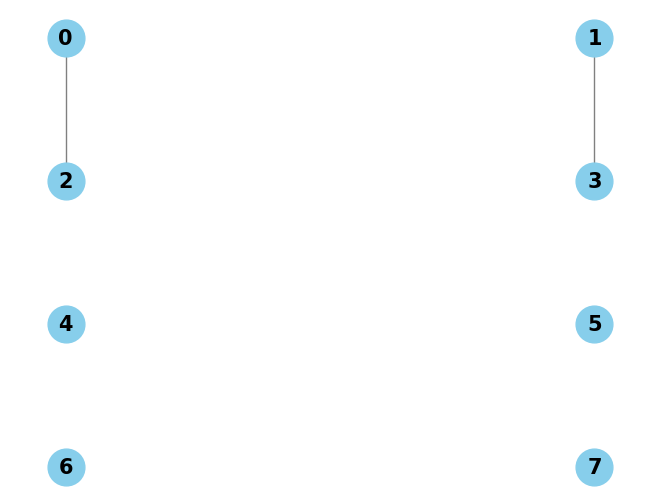

In [3]:
edges = {('000','010'),
         ('001','011')}

G = ParallelEdgeGraph(edges)
G.draw()

In [4]:
print('The Graph Expression: ')
expr = G.expr
display(expr)

The Graph Expression: 


(x_2 & ~x_0) | (~x_0 & ~x_2)

In [5]:
target = G.target
rot_angle = G.rot_angle
print(f'The Target Qubit: {target}')
print(f'We assume a fixed rotation angle: {round(rot_angle, 3)}')

The Target Qubit: 1
We assume a fixed rotation angle: 1.571


The Quantum Circuit: 


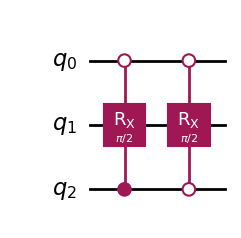

In [6]:
print('The Quantum Circuit: ')
G.get_qc().draw('mpl')

The Quantum Circuit (simplified): 


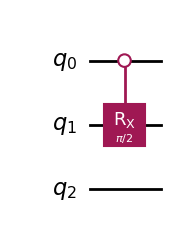

In [7]:
print('The Quantum Circuit (simplified): ')
G.get_qc(simplified=True).draw('mpl')

Target Qubits: [2, 1]


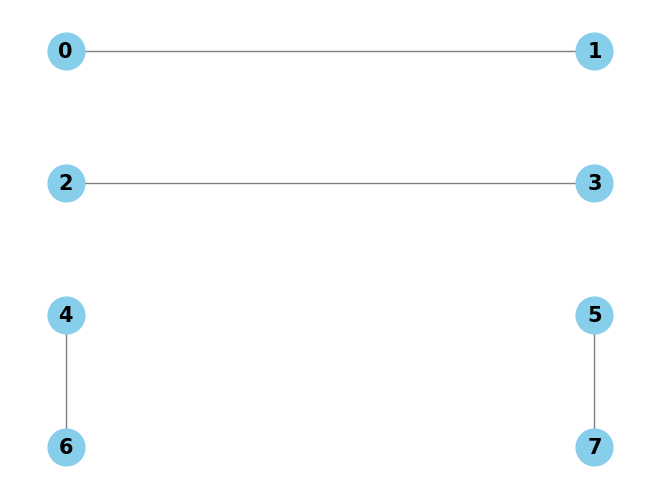

In [8]:
edges = {('000','001'),
         ('010','011'),
         ('100','110'),
         ('101','111')}

G = NonDiagonalEdgeGraph(edges)
print(f'Target Qubits: {G.targets}')
G.draw()

The Quantum Circuit: 


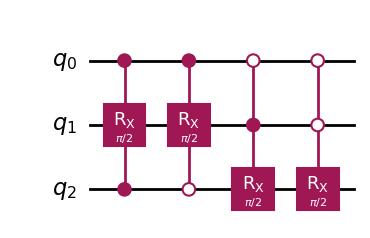

In [9]:
print('The Quantum Circuit: ')
G.get_qc().draw('mpl')

The Quantum Circuit: (simplified)


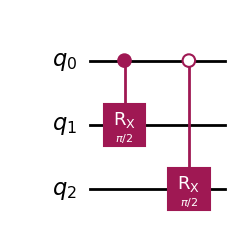

In [10]:
print('The Quantum Circuit: (simplified)')
G_simplified = NonDiagonalEdgeGraph(edges)
G_simplified.get_qc(simplified=True).draw('mpl')

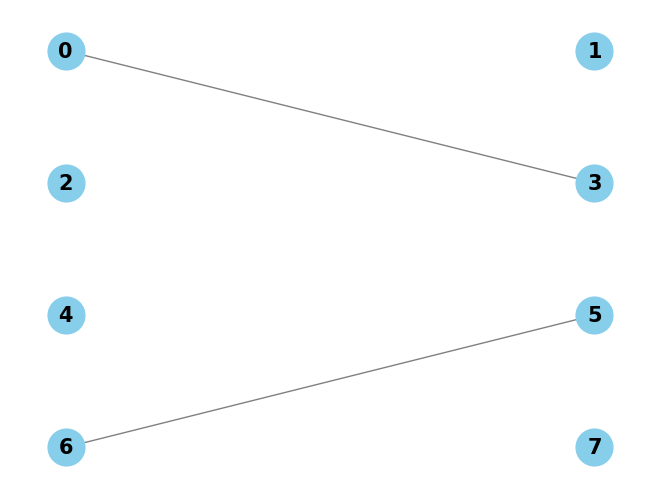

In [11]:
# edges = {('000','011'),
#          ('010','101'),
#          ('110','111')}

# edges = {('000','011'),
#          ('110','111')}

edges = {('000','011'),
         ('101','110')}

G = DiagonalEdgeGraph(edges)
G.draw()

Candidate Graph:


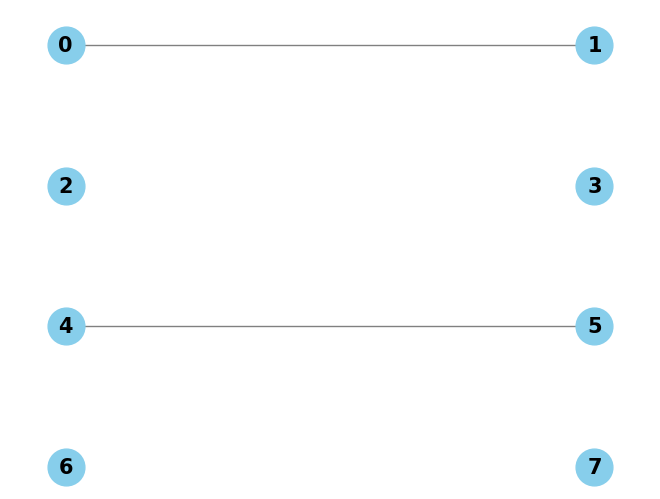

None

Quantum Circuit:


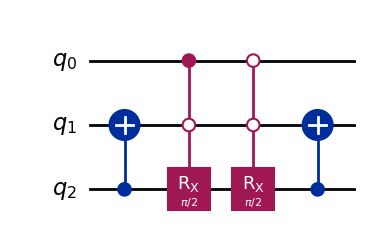

Quantum Circuit (Simplified):


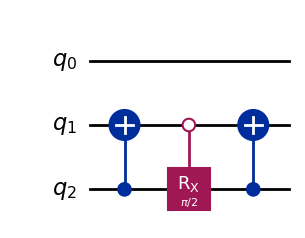

--------------------------------------------------------------------------------------
Candidate Graph:


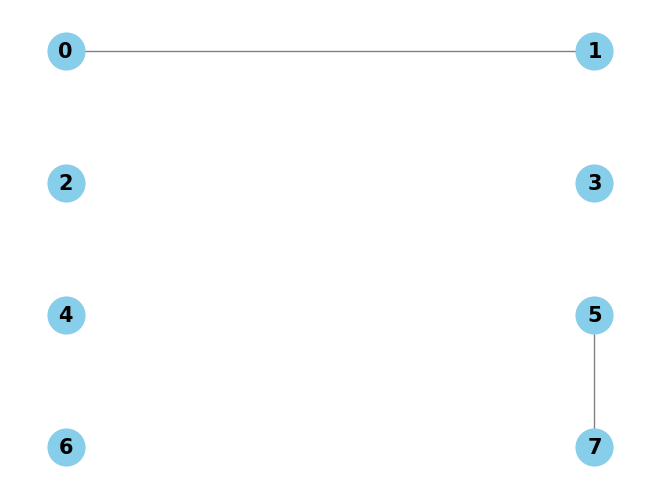

None

Quantum Circuit:


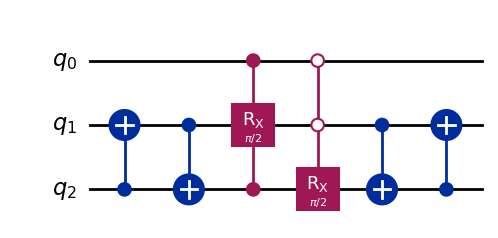

Quantum Circuit (Simplified):


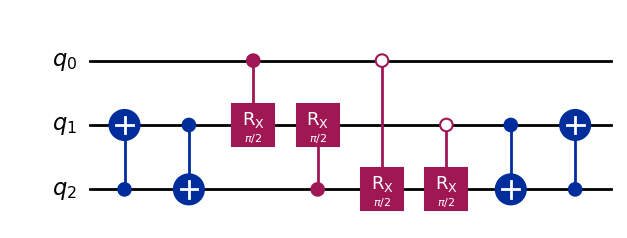

--------------------------------------------------------------------------------------
Candidate Graph:


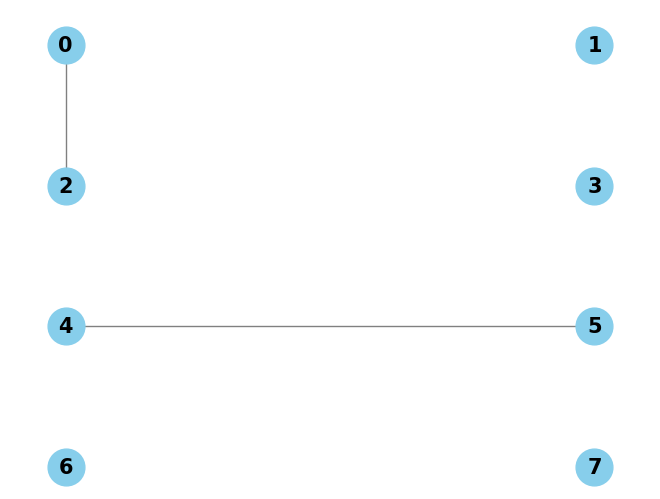

None

Quantum Circuit:


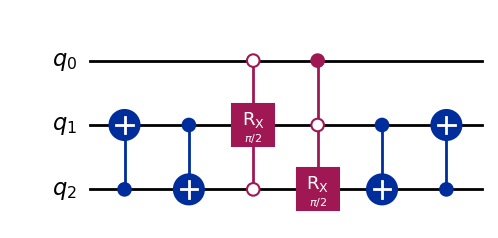

Quantum Circuit (Simplified):


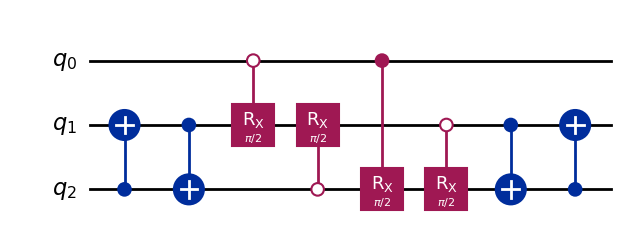

--------------------------------------------------------------------------------------
Candidate Graph:


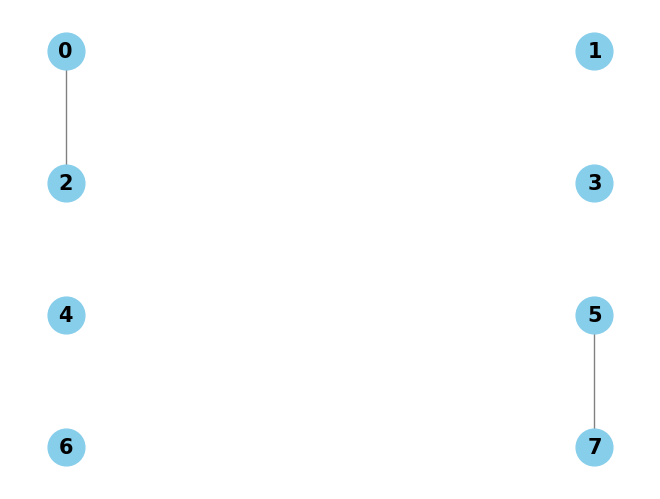

None

Quantum Circuit:


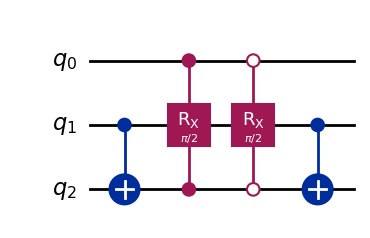

Quantum Circuit (Simplified):


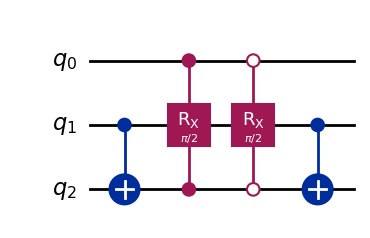

--------------------------------------------------------------------------------------


In [12]:
for e in G.candidates:
    cnots_lists = []
    for t in e.targets:
        cnots = get_cyclic_connections(G.connections, t)
        for cx in cnots:
            if cx not in cnots_lists:  
                cnots_lists.append(cx)
    
    circ = QuantumCircuit(e.n_qubits)
    for t in cnots_lists:
        circ.cx(*t)
    circ.append(e.get_qc(), range(e.n_qubits))
    for t in reversed(cnots_lists):
        circ.cx(*t)

    circ_simplified = QuantumCircuit(e.n_qubits)
    for t in cnots_lists:
        circ_simplified.cx(*t)
    circ_simplified.append(e.get_qc(simplified=True), range(e.n_qubits))
    for t in reversed(cnots_lists):
        circ_simplified.cx(*t)
    
    print('Candidate Graph:')
    display(e.draw())
    print('Quantum Circuit:')
    display(circ.decompose().draw('mpl'))
    print('Quantum Circuit (Simplified):')
    display(circ_simplified.decompose().draw('mpl'))
    print('--------------------------------------------------------------------------------------')